In [9]:
import numpy as np
from sklearn.datasets import make_blobs

X, _ = make_blobs(n_samples=200, centers=3, n_features=3, random_state=0)

X = X - X.mean(axis=0)
cov = np.cov(X,rowvar=False)
eigvals , eigvecs = np.linalg.eig(cov)
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:,idx]

print("Eigenvalues (varience)")
print(eigvals)

print("Check orthogonality")
print(np.round(eigvecs.T @ eigvecs,3)) #identity matrix = orthogonal

Eigenvalues (varience)
[24.73114552  5.11905892  0.88410211]
Check orthogonality
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


Explained varience ratio:
[0.61573774 0.29263181]


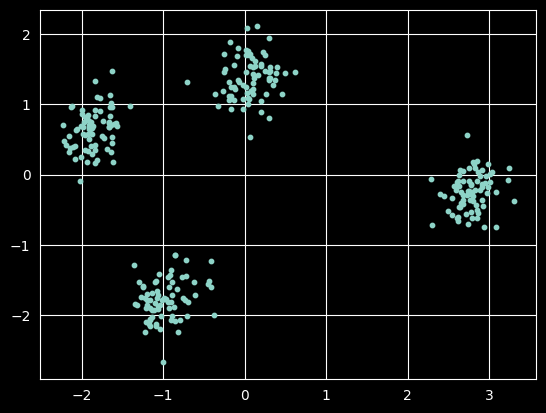

In [10]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

X,_ = make_blobs(n_samples=300, centers=4, n_features=5, random_state=0)
X = StandardScaler().fit_transform(X)
'''
fit() - does the job of calculating how good the data is by calculating its mean, std dev., etc....
transform() - is putting that data into work,declationg that as trainable.
fit_transform() - does both of them at the same time.
'''
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
print("Explained varience ratio:")
print(pca.explained_variance_ratio_)
plt.scatter(X_pca[:,0],X_pca[:,1],s=10)
plt.show()

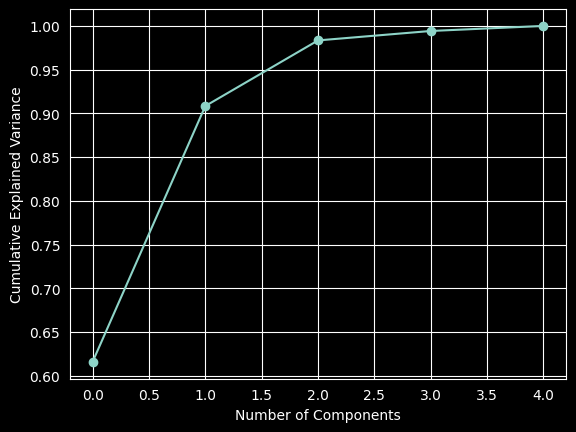

In [11]:
pca_full = PCA().fit(X)
plt.plot(np.cumsum(pca_full.explained_variance_ratio_),marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.show() #scree